### micrograd from scratch

In [2]:
import math
import numpy as np 
import matplotlib.pyplot as plt

In [3]:
def f(x):
    return 3*x**2 - 4*x + 5

In [4]:
f(3.0)

20.0

In [5]:
xs = np.arange(-5, 5, 0.25)
# xs

# these 'y's are also applying a function on every one of these elements independently, 
# so we can use the same function f on the entire array of xs
ys = f(xs)
ys

array([100.    ,  91.6875,  83.75  ,  76.1875,  69.    ,  62.1875,
        55.75  ,  49.6875,  44.    ,  38.6875,  33.75  ,  29.1875,
        25.    ,  21.1875,  17.75  ,  14.6875,  12.    ,   9.6875,
         7.75  ,   6.1875,   5.    ,   4.1875,   3.75  ,   3.6875,
         4.    ,   4.6875,   5.75  ,   7.1875,   9.    ,  11.1875,
        13.75  ,  16.6875,  20.    ,  23.6875,  27.75  ,  32.1875,
        37.    ,  42.1875,  47.75  ,  53.6875])

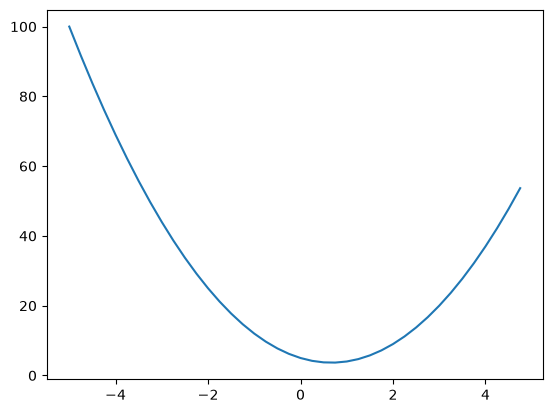

In [6]:
plt.plot(xs, ys)

now want to figure out: what is the derivative of this function at any single input point x ...

In [7]:
h = 0.001
x = -3.0

# value of the function at x
f(x + h)

# slope at 3 = 14
# slope at -3 = -21.996
# slope is 0 at 2/3

(f(x + h) - f(x)) / h

-21.996999999998934

In [8]:
# more complex
a = 2.0
b = -3.0
c = 10.0
d = a*b + c
print(d)

4.0


In [9]:
# derivative of d with respect to a is b
h = 0.0001

# inputs
a = 2.0
b = -3.0
c = 10.0


d1 = a*b + c
c += h 
d2 = a*b + c

print('d1:', d1)
print('d2:', d2)

# d2 - d1 is how much the function increased when bumped the specific input were interested in by a small amount h. 
# then normalized by h to get the slope
print('slope:', (d2 - d1)/h)



d1: 4.0
d2: 4.0001
slope: 0.9999999999976694


In [92]:
# value object
class Value:
    def __init__(self, data, _children=(), _op='', label=''):
        self.data = data
        # grad represents the derivative of the output.
        self.grad = 0.0
        self._backward = lambda: None
        self._prev = set(_children)
        self._op = _op
        self.label = label

    def __repr__(self):
        return f"Value(data={self.data})"
    
    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data + other.data, (self, other), '+')
        def _backward():
            # += not =, so a node used by more than one consumer accumulates
            # contributions from every path instead of the last one winning
            self.grad += 1.0 * out.grad
            other.grad += 1.0 * out.grad
        out._backward = _backward
        return out
    
    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data * other.data, (self, other), '*')
        def _backward():
            self.grad += (other.data * out.grad)
            other.grad += (self.data * out.grad)
        out._backward = _backward
        return out
    
    def tanh(self):
        x = self.data
        t = (math.exp(2*x) - 1) / (math.exp(2*x) + 1)
        out = Value(t, (self,), 'tanh')
        def _backward():
            self.grad += (1 - t**2) * out.grad
        out._backward = _backward
        return out
    
    def __rmul__(self, other):  # other * self
        return self * other
    
    def exp(self):
        x = self.data
        out = Value(math.exp(x), (self,), 'exp')
        def _backward():
            self.grad += out.data * out.grad
        out._backward = _backward
        return out
    
    def __pow__(self, other):  # self ** other
        assert isinstance(other, (int, float)), "only supporting int/float powers for now"
        out = Value(self.data**other, (self,), f'**{other}')
        def _backward():
            self.grad += (other * self.data**(other-1)) * out.grad
        out._backward = _backward
        return out
    
    def __truediv__(self, other):  # self / other
        other = other if isinstance(other, Value) else Value(other)
        return self * other**-1
    
    def __sub__(self, other):  # self - other
        return self + (-other)
    
    def backward(self):
        # topological sort: a node is only appended after all of its children,
        # so reversed(topo) visits every node after everything that depends on it
        topo = []
        visited = set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)
        build_topo(self)

        # now that grads accumulate with +=, stale values from a previous
        # backward pass would be added to instead of overwritten -> zero first
        for node in topo:
            node.grad = 0.0

        self.grad = 1.0  # seed: d(self)/d(self) = 1
        for node in reversed(topo):
            node._backward()



In [12]:
from graphviz import Digraph

def trace(root):
    # builds a set of all nodes and edges in a graph
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)
    build(root)
    return nodes, edges

def draw_dot(root):
    dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) # LR = left to right
    nodes, edges = trace(root)
    for n in nodes:
        uid = str(id(n))
        # create a node for each value object
        dot.node(name=uid, label="{ %s | data %.4f | grad %.4f }" % (n.label, n.data, n.grad), shape='record')
        if n._op:
            # if this node is a result of an operation, create an op node for it
            dot.node(name=uid + n._op, label=n._op)
            dot.edge(uid + n._op, uid)
            
    for n1, n2 in edges:
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)
    return dot


## whats been built

- mathematical expression with multiple inputs (a, b, c, etc)
- math exp. produces a single output L
- visual of the forward pass (value is negative 8)

- next we want to run back propagation
- well start at end and reverse and calculate gradient of the intermidiate values
- were going to compute the derivative of that node with respect to L

"loss function" = L
- its interesting, the derivative of the loss function L,
with respect to the weights of a neural network



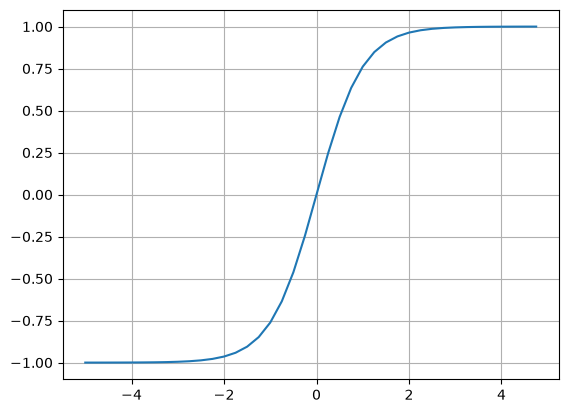

In [24]:
plt.plot(np.arange(-5, 5, 0.25), np.tanh(np.arange(-5, 5, 0.25)))
plt.grid()

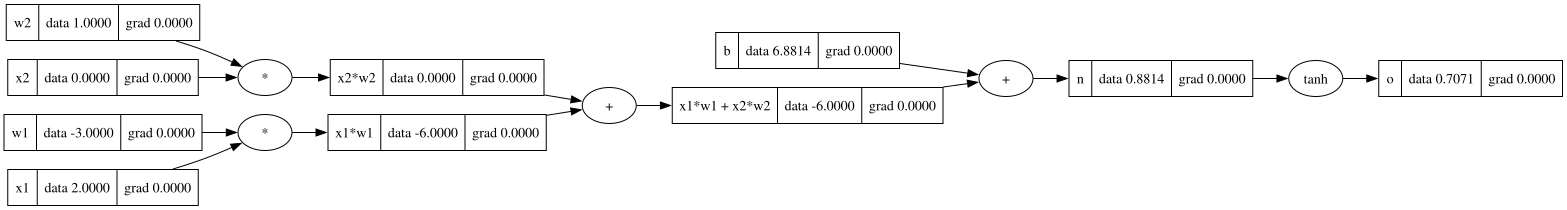

In [77]:
# inputs x1,x2
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')

# weights w1,w2
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')

# bias of the neuron
b = Value(6.8813735870195432, label='b')

# x1*w1 + x2*w2 + b
x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2 = x2*w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'
n = x1w1x2w2 + b; n.label = 'n'

# output
# need to implement a new tanh since tanh is a hyperbolic function, 
# which is a non-linear activation function. and we've only implemented + and * so far.
# you also need exponentiation

o = n.tanh(); o.label = 'o'
draw_dot(o)

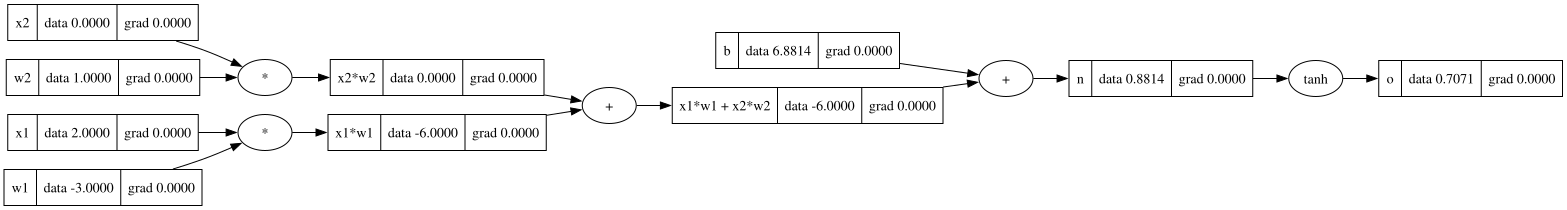

In [65]:
draw_dot(o)

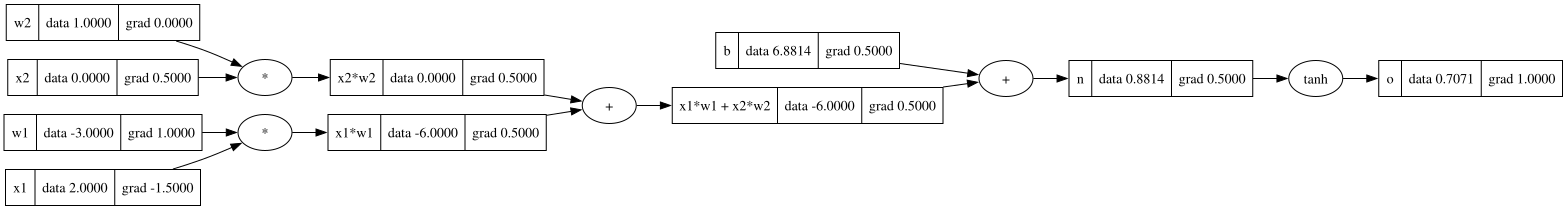

In [78]:
# all of it — topo sort, zeroing, seeding o.grad = 1.0, and the reverse pass —
# now lives in Value.backward()
o.backward()
draw_dot(o)

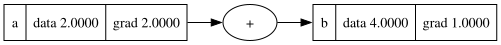

In [79]:
a = Value(2.0, label='a')
b = a + a; b.label = 'b'

b.backward()
draw_dot(b)

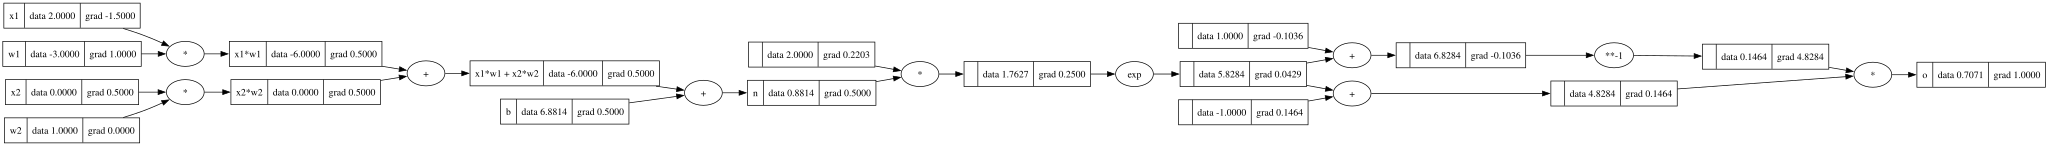

In [93]:
# inputs x1,x2
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')

# weights w1,w2
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')

# bias of the neuron
b = Value(6.8813735870195432, label='b')

# x1*w1 + x2*w2 + b
x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2 = x2*w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'
n = x1w1x2w2 + b; n.label = 'n'

e = (2*n).exp()
o = (e - 1)/(e + 1)

o.label = 'o'
o.backward()
draw_dot(o)